# Activity Prediction (Phase 3) — Structure-Based Validation

Small-scale docking validation of QSAR-selected compounds.
Runs locally on a personal computer (<2h runtime, 10 compounds).

**Inputs:**
- `mol_files/8. Clustering/Thiazolones_10_samples.csv` (ID, SMILES, QSAR_score)
- `protein_files/pdb/6COX.pdb` (COX-2, ligand S58)
- `protein_files/pdb/3KK6.pdb` (COX-1, ligand FLC)

**Workflow:**
1. **PREPARE** — Ligand (multi-conformer) + receptor preparation
2. **DOCK** — AutoDock Vina (exhaustiveness=16, num_modes=3)
3. **SCORE** — Geometric scoring, pose selection, final ranking

**No HPC, no MD, no QSAR training.**

## 0. Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import subprocess
import shutil
import time
import json

import py_utils as pu
import py_utils.docking as dock

print(f"py_utils {pu.__version__}")

# Configuration
ROOT = Path.cwd()
SEED = 42
FORCE_REDOCK = False

# Docking parameters
EXHAUSTIVENESS = 16
NUM_MODES = 3
BOX_SIZE = 22.0

# Input files
INPUT_CSV = ROOT / "mol_files/8. Clustering/Thiazolones_10_samples.csv"
COX2_PDB = ROOT / "protein_files/pdb/6COX.pdb"
COX1_PDB = ROOT / "protein_files/pdb/3KK6.pdb"
COX2_LIGAND = "S58"
COX1_LIGAND = "FLC"

# Receptor map
RECEPTOR_MAP = {"6COX": "COX2", "3KK6": "COX1"}
receptor_pdb_map = {"6COX": str(COX2_PDB), "3KK6": str(COX1_PDB)}

py_utils 5.5


## 0. Create directories

In [2]:
dirs = dock.init_hpc_dirs(ROOT / "hpc_jobs")
print(f"[init] Created {len(dirs)} directories")

[init_hpc_dirs] Created 13 directories under /Users/dariomlorente/code/coxib-drug-design/hpc_jobs
[init] Created 13 directories


## 0b. Initialize pipeline state (restart-safe)

In [3]:
# All intermediate variables initialized to safe defaults.
df_ligands_raw = pd.DataFrame()
df_ligands = pd.DataFrame()
cox2_info = {}
cox1_info = {}
mapping_df = pd.DataFrame()
df_all_poses = pd.DataFrame()
df_best_poses = pd.DataFrame()
df_ranked = pd.DataFrame()
docking_validation = {}

## 1. Prepare ligands and receptors

In [4]:
df_ligands_raw = pd.read_csv(INPUT_CSV)
print(f"[Load ligands] {len(df_ligands_raw)} compounds from {INPUT_CSV.name}")
display(df_ligands_raw[["ID", "SMILES", "QSAR_score"]].head())

[Load ligands] 10 compounds from Thiazolones_10_samples.csv


,ID,SMILES,QSAR_score
0,A40C14S,COc1ccc(/C=C2\N=C(c3ccnc4ccccc34)SC2=O)c(OC)c1OC,8.110302
1,A60C24S,COc1ccccc1/C=C1\N=C(c2c(F)cccc2Br)SC1=O,8.163366
2,A89C27S,C=C(C)/C=C1\N=C(c2ccccn2)SC1=O,7.914900
3,A47C32S,COc1ccc(C2=N/C(=C\c3cccnc3)C(=O)S2)c(Br)c1,8.151053
4,A34C7S,COc1ccc(C2=N/C(=C\c3ccc[nH]3)C(=O)S2)cc1OC,7.843126


In [5]:
df_ligands = dock.prepare_ligands_multi_conf(
    df_ligands_raw,
    dirs["ligands"],
    n_confs=15,
    seed=SEED,
)

[prepare_ligands_multi_conf] 10/10 ligands prepared successfully


In [6]:
# 6COX (COX-2): binding site from co-crystallized SC-558 (S58)
cox2_info = dock.prepare_receptor(
    pdb_path=COX2_PDB,
    receptor_dir=dirs["receptors"],
    receptor_id="6COX",
    ligand_resname=COX2_LIGAND,
    box_size=BOX_SIZE,
)
print(f"\n[prepare_receptor] COX-2 box center: {cox2_info['box_center']}")

# 3KK6 (COX-1): binding site from co-crystallized celecoxib (FLC)
cox1_info = dock.prepare_receptor(
    pdb_path=COX1_PDB,
    receptor_dir=dirs["receptors"],
    receptor_id="3KK6",
    ligand_resname=COX1_LIGAND,
    box_size=BOX_SIZE,
)
print(f"[prepare_receptor] COX-1 box center: {cox1_info['box_center']}")

[prepare_receptor] Generated /Users/dariomlorente/code/coxib-drug-design/hpc_jobs/receptors/6COX.pdbqt
[get_binding_site_center] Using S58 centroid from 6COX.pdb
[prepare_receptor] Saved /Users/dariomlorente/code/coxib-drug-design/hpc_jobs/receptors/6COX_box.json

[prepare_receptor] COX-2 box center: [46.87599999999999, 18.92428846153846, 44.33801923076922]
[prepare_receptor] Generated /Users/dariomlorente/code/coxib-drug-design/hpc_jobs/receptors/3KK6.pdbqt
[get_binding_site_center] Using FLC centroid from 3KK6.pdb
[prepare_receptor] Saved /Users/dariomlorente/code/coxib-drug-design/hpc_jobs/receptors/3KK6_box.json
[prepare_receptor] COX-1 box center: [-41.060722222222225, 66.59022222222224, -1.4707777777777777]


In [7]:
for rec_id, info in [("6COX", cox2_info), ("3KK6", cox1_info)]:
    if not info:
        print(f"\n{rec_id}: not prepared")
        continue
    box_path = dirs["receptors"] / f"{rec_id}_box.json"
    with open(box_path) as f:
        box = json.load(f)
    print(f"\n{rec_id}:")
    print(f"  Center: ({box['center_x']}, {box['center_y']}, {box['center_z']})")
    print(f"  Size: {box['size_x']} x {box['size_y']} x {box['size_z']} A")


6COX:
  Center: (46.876, 18.924, 44.338)
  Size: 22.0 x 22.0 x 22.0 A

3KK6:
  Center: (-41.061, 66.59, -1.471)
  Size: 22.0 x 22.0 x 22.0 A


## 2. Run docking

In [8]:
if len(df_ligands) > 0:
    mapping_path = dock.write_mapping_csv(
        df_ligands=df_ligands,
        receptor_ids=["6COX", "3KK6"],
        mapping_csv=dirs["docking_inputs"] / "mapping.csv",
    )
    mapping_df = pd.read_csv(mapping_path)
    print(f"[docking mapping] {len(mapping_df)} tasks (10 ligands x 2 receptors)")
    display(mapping_df.head())
else:
    print("[docking mapping] No ligands available")

[write_mapping_csv] 20 docking tasks written to /Users/dariomlorente/code/coxib-drug-design/hpc_jobs/docking/inputs/mapping.csv
[docking mapping] 20 tasks (10 ligands x 2 receptors)


,task_id,ligand_id,receptor_id
0,1,A40C14S,6COX
1,2,A40C14S,3KK6
2,3,A60C24S,6COX
3,4,A60C24S,3KK6
4,5,A89C27S,6COX


In [9]:
vina_exe = shutil.which("vina")
if vina_exe is None:
    raise RuntimeError(
        "AutoDock Vina not found. Install with: "
        "conda install -c conda-forge vina=1.2.5"
    )
print(f"[docking] Using Vina at: {vina_exe}")

if mapping_df.empty:
    print("[docking] No mapping available")
else:
    logs_dir = dirs["docking_logs"]
    results_dir = dirs["docking_results"]
    ligands_dir = dirs["ligands"]
    receptors_dir = dirs["receptors"]

    # Load box configs
    box_configs = {}
    for rec_id in ["6COX", "3KK6"]:
        box_path = receptors_dir / f"{rec_id}_box.json"
        with open(box_path) as f:
            box_configs[rec_id] = json.load(f)

    n_done = 0
    n_skipped = 0
    n_failed = 0
    start = time.time()

    for _, task in mapping_df.iterrows():
        ligand_id = task["ligand_id"]
        receptor_id = task["receptor_id"]

        log_path = logs_dir / f"{ligand_id}_{receptor_id}.log"
        pose_path = results_dir / f"{ligand_id}_{receptor_id}_out.pdbqt"

        if log_path.exists() and pose_path.exists() and not FORCE_REDOCK:
            n_skipped += 1
            continue

        ligand_pdbqt = ligands_dir / f"{ligand_id}.pdbqt"
        receptor_pdbqt = receptors_dir / f"{receptor_id}.pdbqt"
        box = box_configs[receptor_id]

        if not ligand_pdbqt.exists() or not receptor_pdbqt.exists():
            print(f"[docking] Missing input for {ligand_id} x {receptor_id}")
            n_failed += 1
            continue

        cmd = [
            vina_exe,
            "--receptor", str(receptor_pdbqt),
            "--ligand", str(ligand_pdbqt),
            "--center_x", str(box["center_x"]),
            "--center_y", str(box["center_y"]),
            "--center_z", str(box["center_z"]),
            "--size_x", str(box["size_x"]),
            "--size_y", str(box["size_y"]),
            "--size_z", str(box["size_z"]),
            "--cpu", "4",
            "--exhaustiveness", str(EXHAUSTIVENESS),
            "--num_modes", str(NUM_MODES),
            "--out", str(pose_path),
        ]

        result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
        with open(log_path, "w") as f:
            f.write(result.stdout)
            if result.stderr:
                f.write(result.stderr)

        if result.returncode == 0:
            n_done += 1
            print(f"  [{n_done + n_skipped}/{len(mapping_df)}] {ligand_id} x {receptor_id} done")
        else:
            n_failed += 1
            print(f"  FAILED: {ligand_id} x {receptor_id}: {result.stderr[:200]}")

    elapsed = time.time() - start
    print(f"\n[docking] {n_done} completed, {n_skipped} skipped, {n_failed} failed")
    print(f"[docking] Total time: {elapsed/60:.1f} min")

[docking] Using Vina at: /Users/dariomlorente/miniconda3/envs/docking/bin/vina

[docking] 0 completed, 20 skipped, 0 failed
[docking] Total time: 0.0 min


## 3. Validate and parse results

In [10]:
docking_validation = dock.validate_docking_results(
    mapping_csv=dirs["docking_inputs"] / "mapping.csv",
    logs_dir=dirs["docking_logs"],
    results_dir=dirs["docking_results"],
)
if docking_validation["status"] == "FAIL":
    print("No valid docking results. Run docking first.")
elif docking_validation["status"] == "PARTIAL":
    print(f"Partial results: {docking_validation['complete']}/{docking_validation['total']} tasks validated.")
    print("Downstream analysis will use only validated tasks.")

[validate_docking] PASS: 20/20 docking tasks validated. Missing: 0, Failed: 0, Orphaned: 0


In [11]:
if docking_validation.get("status") in ("PASS", "PARTIAL"):
    df_all_poses = dock.extract_all_docking_scores(
        logs_dir=dirs["docking_logs"],
        receptor_map=RECEPTOR_MAP,
        n_modes=NUM_MODES,
    )
    print(f"[parse poses] {len(df_all_poses)} poses extracted ({NUM_MODES} per task max)")
    display(df_all_poses.head(10))
else:
    df_all_poses = pd.DataFrame()
    print("[parse poses] No valid docking results")

[parse poses] 60 poses extracted (3 per task max)


,ligand_id,receptor_id,cox_label,pose_rank,docking_score
0,A42C30S,3KK6,COX1,1,-8.42
1,A42C30S,3KK6,COX1,2,-8.23
2,A42C30S,3KK6,COX1,3,-7.99
3,A40C14S,3KK6,COX1,1,-7.30
4,A40C14S,3KK6,COX1,2,-7.17
5,A40C14S,3KK6,COX1,3,-7.15
6,A89C27S,3KK6,COX1,1,-6.42
7,A89C27S,3KK6,COX1,2,-6.14
8,A89C27S,3KK6,COX1,3,-6.13
9,A78C7S,3KK6,COX1,1,-8.07


## 4. Geometric scoring and pose selection

In [12]:
if not df_all_poses.empty:
    df_best_poses = dock.select_best_poses_by_geo_score(
        df_all_poses,
        results_dir=dirs["docking_results"],
        receptor_pdb_map=receptor_pdb_map,
    )
    print(f"[best poses] {len(df_best_poses)} ligand-receptor pairs evaluated")
    display(df_best_poses.head(10))
else:
    df_best_poses = pd.DataFrame()

    Clashes: 0 (running score: 1.0)
    Clashes: 0 (running score: 1.0)
    Clashes: 0 (running score: 1.0)
    Side pocket: fraction=0.71 (+1)
    Clashes: 0 (running score: 2.0)
    Side pocket: fraction=0.71 (+1)
    Clashes: 0 (running score: 2.0)
    Side pocket: fraction=0.71 (+1)
    Clashes: 0 (running score: 2.0)
    Clashes: 0 (running score: 1.0)
    Clashes: 0 (running score: 1.0)
    Clashes: 0 (running score: 1.0)
    Side pocket: fraction=0.70 (+1)
    Clashes: 0 (running score: 2.0)
    Side pocket: fraction=0.70 (+1)
    Clashes: 0 (running score: 2.0)
    Side pocket: fraction=0.70 (+1)
    Clashes: 0 (running score: 2.0)
    Side pocket: fraction=0.87 (+1)
    Clashes: 0 (running score: 2.0)
    Side pocket: fraction=0.87 (+1)
    Clashes: 0 (running score: 2.0)
    Side pocket: fraction=0.87 (+1)
    Clashes: 0 (running score: 2.0)
    Clashes: 0 (running score: 1.0)
    Clashes: 0 (running score: 1.0)
    Clashes: 0 (running score: 1.0)
    Clashes: 0 (running scor

,ligand_id,receptor_id,cox_label,best_pose_rank,docking_score,geometric_score
0,A42C30S,3KK6,COX1,1,-8.42,0.0
1,A42C30S,6COX,COX2,1,-9.01,1.0
2,A40C14S,3KK6,COX1,1,-7.30,0.0
3,A40C14S,6COX,COX2,1,-7.73,2.0
4,A89C27S,3KK6,COX1,1,-6.42,0.0
5,A89C27S,6COX,COX2,1,-6.59,1.0
6,A78C7S,3KK6,COX1,1,-8.07,0.0
7,A78C7S,6COX,COX2,1,-7.63,2.0
8,A60C24S,3KK6,COX1,1,-7.38,0.0
9,A60C24S,6COX,COX2,1,-7.91,2.0


## 5. Final ranking

In [13]:
if not df_best_poses.empty:
    df_ranked = dock.compute_final_ranking(
        df_best_poses,
        df_ligands_raw,
    )
    print(f"[final ranking] {len(df_ranked)} compounds ranked")
    display_cols = [
        "ligand_id", "QSAR_score", "score_cox2", "score_cox1",
        "geometric_score", "qsar_norm", "geo_norm", "vina_norm", "final_score",
    ]
    available_cols = [c for c in display_cols if c in df_ranked.columns]
    display(df_ranked[available_cols].round(4))
else:
    df_ranked = pd.DataFrame()

[compute_final_ranking] Scores computed for 10 compounds
[compute_final_ranking] Formula: final_score = 0.5*qsar_norm + 0.4*geo_norm + 0.1*vina_norm
[final ranking] 10 compounds ranked


,ligand_id,QSAR_score,score_cox2,score_cox1,qsar_norm,geo_norm,vina_norm,final_score
0,A42C30S,7.8816,-9.01,-8.42,0.8889,0.3333,1.0000,0.6778
1,A40C14S,8.1103,-7.73,-7.30,0.5556,0.8889,0.3333,0.6667
2,A34C7S,7.8431,-7.70,-7.06,1.0000,0.3333,0.2222,0.6556
3,A60C24S,8.1634,-7.91,-7.38,0.3333,0.8889,0.6667,0.5889
4,A70C29S,7.9440,-7.81,-7.76,0.6667,0.3333,0.5556,0.5222
5,A89C27S,7.9149,-6.59,-6.42,0.7778,0.3333,0.0000,0.5222
6,A78C7S,8.1717,-7.63,-8.07,0.2222,0.8889,0.1111,0.4778
7,A47C32S,8.1511,-7.79,-7.61,0.4444,0.3333,0.4444,0.4000
8,A70C39S,8.6526,-7.97,-8.06,0.1111,0.3333,0.8889,0.2778
9,A13C37S,8.7972,-7.94,-7.87,0.0000,0.3333,0.7778,0.2111


## 6. Output

In [14]:
if not df_ranked.empty:
    output_path = ROOT / "protein_files/docking/docking_scores.csv"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df_ranked.to_csv(output_path, index=False)
    print(f"[save] {len(df_ranked)} compounds saved to {output_path}")
else:
    print("[save] No data to save")

[save] 10 compounds saved to /Users/dariomlorente/code/coxib-drug-design/protein_files/docking/docking_scores.csv


In [15]:
output_poses_dir = ROOT / "protein_files/docking/poses"
output_poses_dir.mkdir(parents=True, exist_ok=True)

if not df_ranked.empty:
    for _, row in df_ranked.iterrows():
        ligand_id = row["ligand_id"]
        for receptor_id in ["6COX", "3KK6"]:
            src = dirs["docking_results"] / f"{ligand_id}_{receptor_id}_out.pdbqt"
            if src.exists():
                dst = output_poses_dir / f"{ligand_id}_{receptor_id}.pdbqt"
                dst.write_bytes(src.read_bytes())

    print(f"[poses] Poses saved to {output_poses_dir}")
else:
    print("[poses] No poses to save")

[poses] Poses saved to /Users/dariomlorente/code/coxib-drug-design/protein_files/docking/poses


## 7. Visualization (optional)

[visualization] Best compound: A42C30S


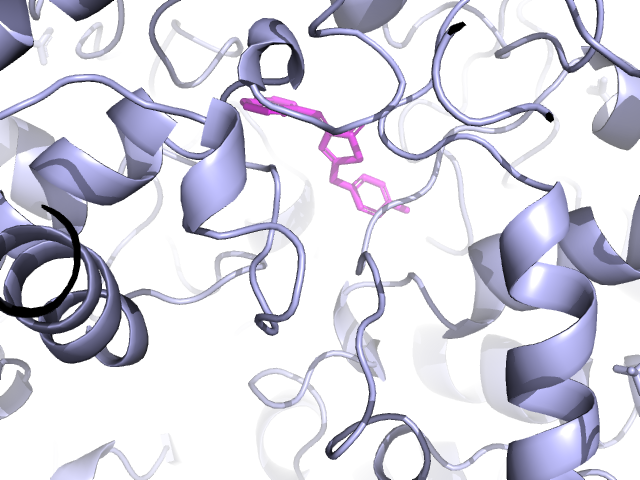

In [16]:
try:
    import subprocess
    from pathlib import Path
    from IPython.display import Image, display

    if not df_ranked.empty:
        best_id = df_ranked.iloc[0]["ligand_id"]
        print(f"[visualization] Best compound: {best_id}")

        ligand_pdbqt = dirs["docking_results"] / f"{best_id}_6COX_out.pdbqt"
        receptor_pdb = COX2_PDB
        output_dir = ROOT / "protein_files/docking/figures"
        output_png = output_dir / f"{best_id}_6COX.png"

        if ligand_pdbqt.exists():
            output_dir.mkdir(parents=True, exist_ok=True)
            result = subprocess.run(
                [
                    "python", "scripts/visualize_pose.py",
                    "--ligand", str(ligand_pdbqt),
                    "--receptor", str(receptor_pdb),
                    "--output", str(output_png),
                ],
                capture_output=True, text=True, timeout=120,
            )
            if result.returncode == 0 and output_png.exists():
                display(Image(filename=str(output_png)))
            else:
                print(f"[visualization] Failed: {result.stderr[-500:]}")
        else:
            print(f"[visualization] Pose not found: {ligand_pdbqt.name}")
    else:
        print("[visualization] No ranking data available")
except Exception as e:
    print(f"[visualization] Error: {e}")
